In [1]:
!pip install -r ../requirements.txt

In [3]:
import sys
import importlib
import numpy as np
sys.path.append("..")

# Import your modules first
import helper
import obelix
import algorithms.d3qn_per_agent as d3qn_per_agent
import configurations.config_p1_sub5 as config_path

# Reload them to pick up any changes
importlib.reload(helper)
importlib.reload(obelix)
importlib.reload(d3qn_per_agent)
importlib.reload(config_path)

device used:  cuda


<module 'configurations.config_p1_sub5' from 'c:\\Users\\hgoel\\MTech_Resources\\DRL\\Capstone_Project\\CS780-OBELIX\\run_scripts\\..\\configurations\\config_p1_sub5.py'>

In [4]:
from helper import plotQuantity
from obelix import OBELIX
from algorithms.d3qn_per_agent import D3QN_PER
from configurations.config_p1_sub5 import config

In [5]:
env = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=False,
    difficulty=0,
    box_speed=2
)
d3qnPerAgent = D3QN_PER(env, config)

In [6]:
print(config)

{'seed': 333, 'gamma': 0.999, 'bufferSize': 100000, 'batchSize': 32, 'optimizerFn': <class 'torch.optim.adam.Adam'>, 'optimizerLR': 0.001, 'MAX_TRAIN_EPISODES': 150, 'MAX_EVAL_EPISODES': 5, 'updateFrequency': 500, 'explorationStrategyTrainFn': <function selectEpsilonGreedyAction at 0x000001A32469B400>, 'explorationStrategyEvalFn': <function selectGreedyAction at 0x000001A32469B5B0>, 'max_steps': 1000, 'epsilon': 0.58, 'eps_decay_strategy': [('linear', {'s': 0, 'e': 149, 'ival': 1.0, 'fval': 0.00145})], 'device': device(type='cuda'), 'delta': 1.0, 'tau': 0.35, 'alpha': 0.81, 'beta': 0.29, 'beta_rate': 0.0002, 'hDim': [128, 64], 'model_path': '../model_weights_phase1_sub5', 'loss_fn': 'HuberLoss'}


In [7]:
d3qnPerTrainRewardsList, d3qnPerTrainTimeList, d3qnPerEvalRewardsList, d3qnPerWallClockTimeList, d3qnPerTotalStepsList, d3qnPerFinalEvalReward = d3qnPerAgent.runD3QN_PER()

Episode 0: TR -37200.0 | ER -983.2 | TT 21.61279320716858 | WC 64.73994755744934 | TS 1000
Episode 1: TR -993.0 | ER -192159.2 | TT 75.80209231376648 | WC 130.595356464386 | TS 1000
Episode 2: TR -9000.0 | ER -989.6 | TT 144.36727499961853 | WC 206.094500541687 | TS 1000
Episode 3: TR -13400.0 | ER -994.4 | TT 220.27537727355957 | WC 282.6832859516144 | TS 1000
Episode 4: TR -8400.0 | ER -994.4 | TT 296.6380124092102 | WC 356.4510986804962 | TS 1000
Episode 5: TR -29800.0 | ER -993.6 | TT 370.17555594444275 | WC 430.1038680076599 | TS 1000
Episode 6: TR -43400.0 | ER -1000.0 | TT 443.9715905189514 | WC 503.8539514541626 | TS 1000
Episode 7: TR -3984.0 | ER -191719.2 | TT 517.7620074748993 | WC 578.7742319107056 | TS 1000
Episode 8: TR -15572.0 | ER -196579.8 | TT 592.7749333381653 | WC 652.7743198871613 | TS 1000
Episode 9: TR -30200.0 | ER -989.4 | TT 667.6557919979095 | WC 729.6000645160675 | TS 1000
Episode 10: TR -9400.0 | ER -985.6 | TT 739.9995307922363 | WC 780.8414015769958 | T

In [8]:
print(f"D3QN_PER Final Evaluation Reward: {np.mean(d3qnPerFinalEvalReward).item()}")

D3QN_PER Final Evaluation Reward: -986.4


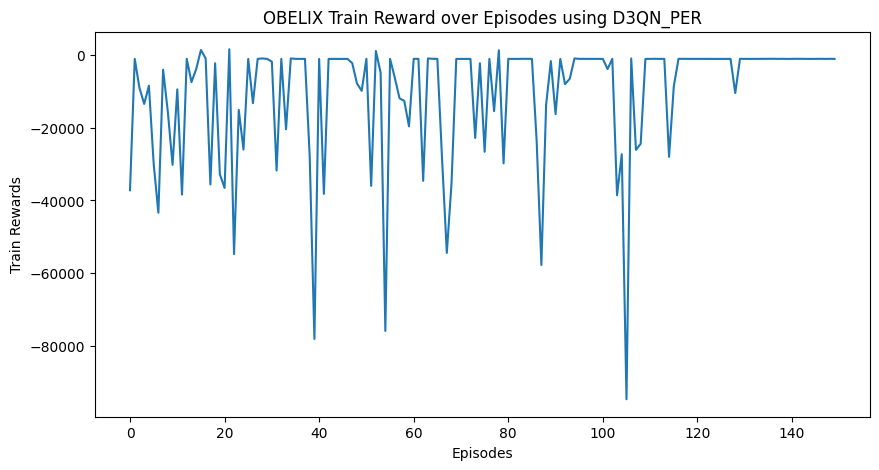

In [9]:
plotQuantity(
    d3qnPerTrainRewardsList, 
    len(d3qnPerTrainRewardsList), 
    descriptionList = ["Episodes", "Train Rewards", "OBELIX Train Reward over Episodes using D3QN_PER"]    
)

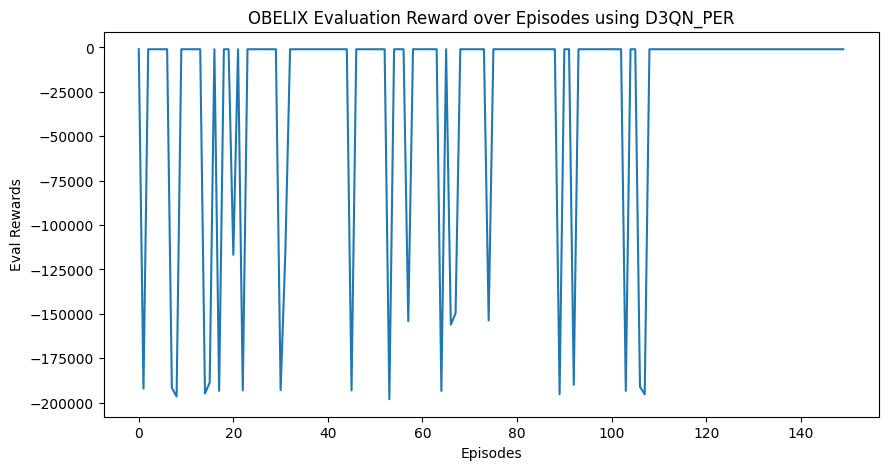

In [10]:
plotQuantity(
    d3qnPerEvalRewardsList, 
    len(d3qnPerEvalRewardsList), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX Evaluation Reward over Episodes using D3QN_PER"]    
)

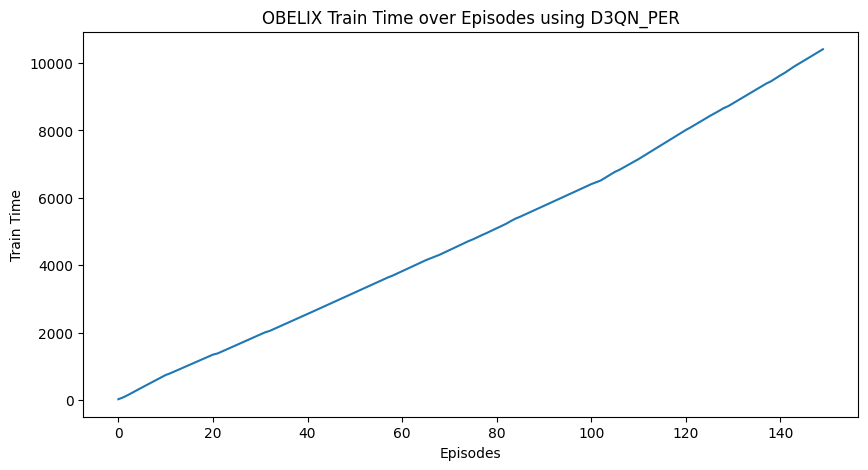

In [11]:
plotQuantity(
    d3qnPerTrainTimeList, 
    len(d3qnPerTrainTimeList), 
    descriptionList = ["Episodes", "Train Time", "OBELIX Train Time over Episodes using D3QN_PER"]    
)

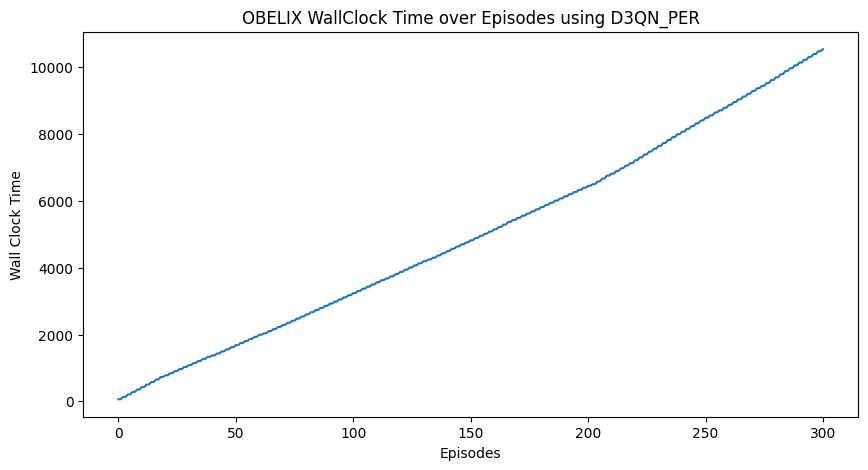

In [12]:
plotQuantity(
    d3qnPerWallClockTimeList, 
    len(d3qnPerWallClockTimeList), 
    descriptionList = ["Episodes", "Wall Clock Time", "OBELIX WallClock Time over Episodes using D3QN_PER"]    
)

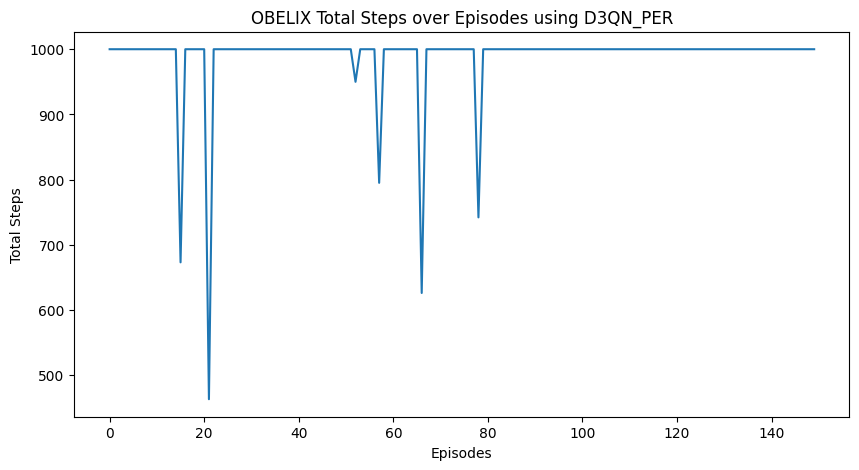

In [13]:
plotQuantity(
    d3qnPerTotalStepsList, 
    len(d3qnPerTotalStepsList), 
    descriptionList = ["Episodes", "Total Steps", "OBELIX Total Steps over Episodes using D3QN_PER"]    
)